In [1]:
from google.colab import files
import pickle
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

import tensorflow as tf # to convert to onehot intuitively using to_categorical

In [ ]:
files.upload() # upload pickle file from local drive

In [4]:
predictions = pickle.load(open('team2_test_preds.pkl', 'rb')) # load pickle file that was just uploaded
test_binary_labels = pd.read_csv('test_binary_labels.csv', header=None)  # Filepath to test binary labels
test_binary_labels_one_hot = pd.DataFrame(np.eye(2)[test_binary_labels.values.reshape(1500).astype(int)])
test_multiclass_labels = pd.read_csv('test_multiclass_labels.csv', header=None) # Filepath to test multiclass labels

print(test_multiclass_labels.shape)
print(test_binary_labels_one_hot.shape)

test_binary_labels_pnehot = tf.keras.utils.to_categorical(test_binary_labels, 2).astype(np.float32)
test_multiclass_labels_onehot = tf.keras.utils.to_categorical(test_multiclass_labels, 5).astype(np.float32)

if predictions.shape[1] == 4:
   classifier_type = 'binary'
else:
   classifier_type = 'multiclass'
print(f'evaluating {classifier_type} classifier')

predictions # check to make sure everything is in the right format


(1500, 1)
(1500, 2)
evaluating binary classifier


,0,1,Unique_Index,predicted_class
0,0.925425,0.074575,5500,0
1,0.904134,0.095866,5501,0
2,0.999030,0.000970,5502,0
3,0.381487,0.618513,5503,1
4,0.937134,0.062866,5504,0
...,...,...,...,...
1495,0.089719,0.910281,6995,1
1496,0.417059,0.582941,6996,1
1497,0.124817,0.875183,6997,1
1498,0.608153,0.391847,6998,0


In [5]:
## Write the column keys corresponding to entry so the dataframe can be read properly

ID_col = 'Unique_Index'  # whatever they named the col with their unique IDs/indexes
guess_col = 'predicted_class'   # whatever they named the col with their guesses
prob_zero =  0    # whatever they named the col with their probs
prob_one =   1      # etc.
prob_two =   2
prob_three = 3
prob_four =  4


In [7]:
predictions = predictions.sort_values([ID_col])   # Sorting to put IDs/Indices in order

if classifier_type == 'binary':
  #binary classifier
  predictions = predictions.reindex([guess_col, prob_zero, prob_one, ID_col], axis=1)  # for binary classifier, putting columns in order
else:
  #multiclass classifier
  predictions = predictions.reindex([guess_col, prob_zero, prob_one, prob_two, prob_three, prob_four, ID_col], axis=1)  # for multiclass classifier, putting columns in order

predictions # look to see if indices/IDs are in order

,predicted_class,0,1,Unique_Index
0,0,0.925425,0.074575,5500
1,0,0.904134,0.095866,5501
2,0,0.999030,0.000970,5502
3,1,0.381487,0.618513,5503
4,0,0.937134,0.062866,5504
...,...,...,...,...
1495,1,0.089719,0.910281,6995
1496,1,0.417059,0.582941,6996
1497,1,0.124817,0.875183,6997
1498,0,0.608153,0.391847,6998


In [8]:
def evaluate(predictions, test_binary_labels, test_multiclass_labels, test_multiclass_labels_one_hot, guess_col, prob_zero,
             prob_one, prob_two, prob_three, prob_four, classifier_type): #classifier type either 'binary' or 'multiclass'

    binary_confmat_score = np.array([[2, -3],
                                     [-6, 2]])

    multiclass_confmat_score = np.array([[2,-1,-1,-3,-3],
                                         [-2,2,-1,-3,-3],
                                         [-2,-1,2,-3,-3],
                                         [-6,-4,-4,2,-2],
                                         [-6,-4,-4,-2,2]])


    if(classifier_type == 'binary'):
        confmat = confusion_matrix(test_binary_labels.values.reshape(1500), predictions[guess_col])
        acc_score = accuracy_score(test_binary_labels.values.reshape(1500), predictions[guess_col])
        confmat_score = np.sum(confmat * binary_confmat_score)

        print(confmat)

        fpr, tpr, thresholds = metrics.roc_curve(test_binary_labels.values.reshape(1500), predictions[prob_one], pos_label=1)
        roc_auc = metrics.auc(fpr, tpr)

    if(classifier_type == 'multiclass'):
        confmat = confusion_matrix(test_multiclass_labels.values.reshape(1500), predictions[guess_col])
        acc_score = accuracy_score(test_multiclass_labels.values.reshape(1500), predictions[guess_col])
        confmat_score = np.sum(confmat * multiclass_confmat_score)

        print(confmat)

        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        for i in range(5):
            fpr[i], tpr[i], _ = metrics.roc_curve(test_multiclass_labels_onehot[:,i], predictions.drop([guess_col, ID_col], axis = 1).iloc[:, i])
            roc_auc[i] = metrics.auc(fpr[i], tpr[i])

        fpr["micro"], tpr["micro"], _ = metrics.roc_curve(test_multiclass_labels_onehot.ravel(), predictions.drop([guess_col, ID_col], axis = 1).values.ravel())
        roc_auc = metrics.auc(fpr["micro"], tpr["micro"])

    return('Confusion Matrix Score:' + str(confmat_score), 'Roc_Auc:' + str(roc_auc), "Accuracy: " + str(acc_score))


In [9]:
evaluate(predictions, test_binary_labels, test_multiclass_labels, test_multiclass_labels_onehot, guess_col, prob_zero,
         prob_one, prob_two, prob_three, prob_four, classifier_type=classifier_type)

[[658  92]
 [ 84 666]]


('Confusion Matrix Score:1868',
 'Roc_Auc:0.9570311111111112',
 'Accuracy: 0.8826666666666667')

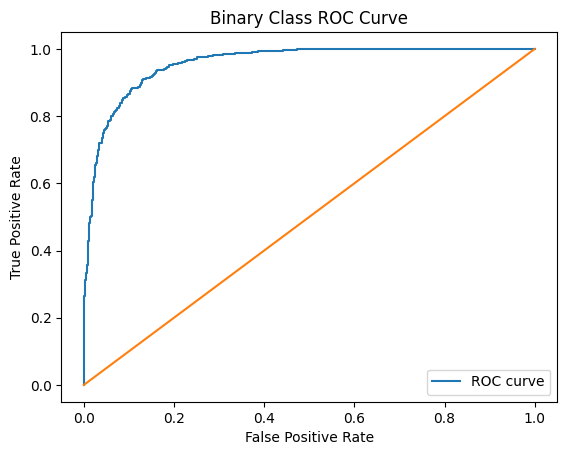

In [10]:
# AUC for binary classifier

fpr, tpr, thresholds = metrics.roc_curve(test_binary_labels.values.reshape(1500), predictions[prob_one], pos_label=1)
roc_auc = metrics.auc(fpr, tpr)
plt.plot(fpr, tpr, label = 'ROC curve')
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary Class ROC Curve')
plt.legend()
plt.show()

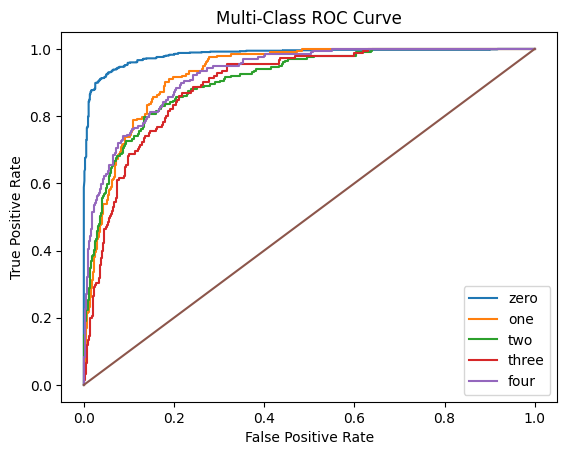

In [ ]:
# AUC for multiclass classifier
fpr = dict()
tpr = dict()
roc_auc = dict()
labels = ['zero', 'one', 'two', 'three', 'four']
for i in range(5):
    fpr[i], tpr[i], _ = metrics.roc_curve(test_multiclass_labels_onehot[:, i], predictions.drop([guess_col, ID_col], axis = 1).iloc[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label = labels[i])
plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

## Troubleshooting tips:

* If a student pickles a file in python 2 you will have to read the pickle file using python 2 (Runtime > Change Runtime Type)